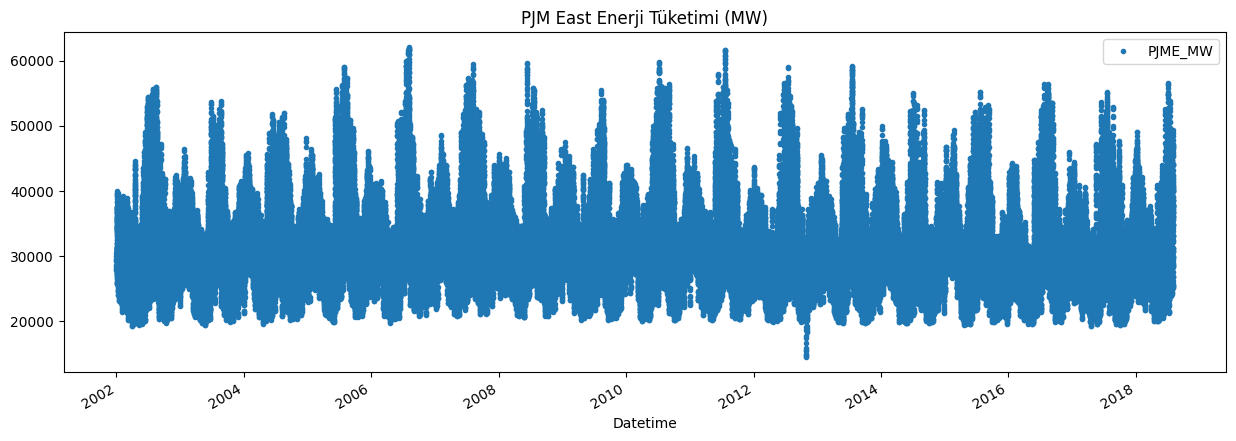

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/PJME_hourly.csv')

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index() 

df.plot(style='.', figsize=(15, 5), color=sns.color_palette()[0], title='PJM East Enerji Tüketimi (MW)')
plt.show()

In [2]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)
df.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1


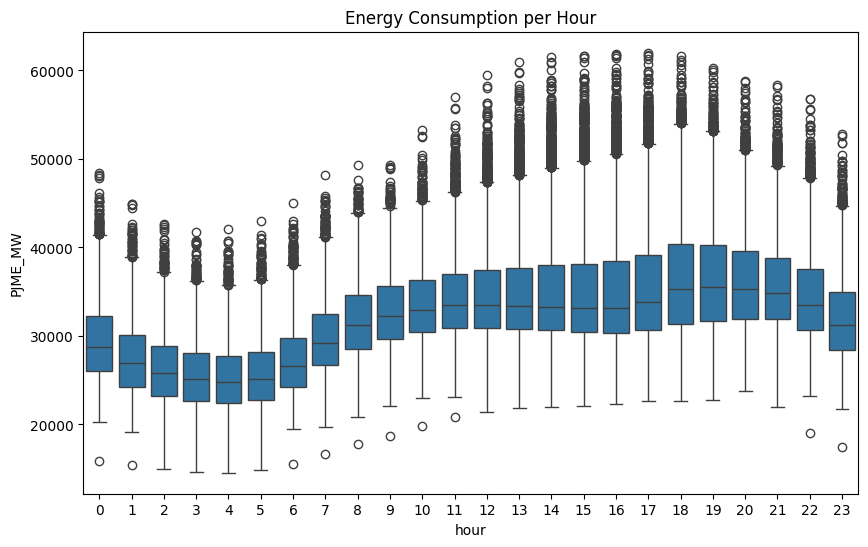

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hour', y='PJME_MW')
plt.title('Energy Consumption per Hour')
plt.show()

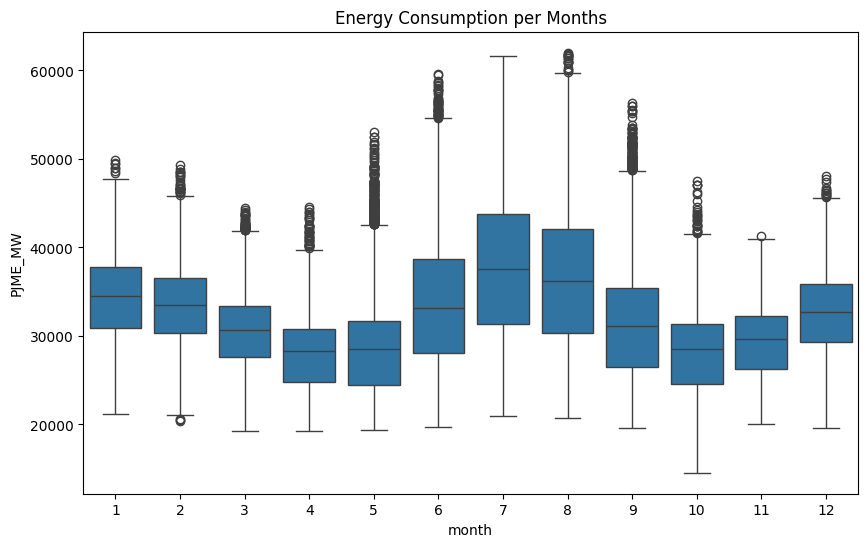

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='month', y='PJME_MW')
plt.title('Energy Consumption per Months')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

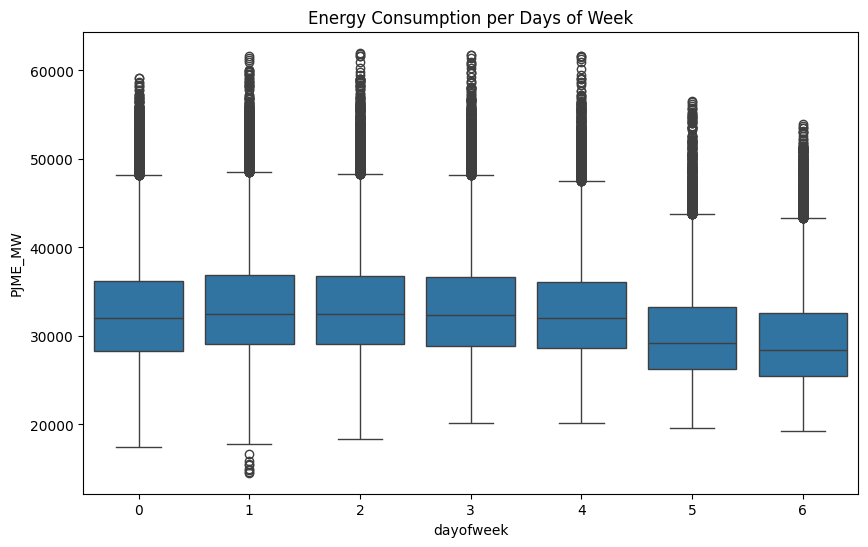

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='dayofweek', y='PJME_MW')
plt.title("Energy Consumption per Days of Week")
plt.show

Training set: 113926 row
Test set: 31440 row


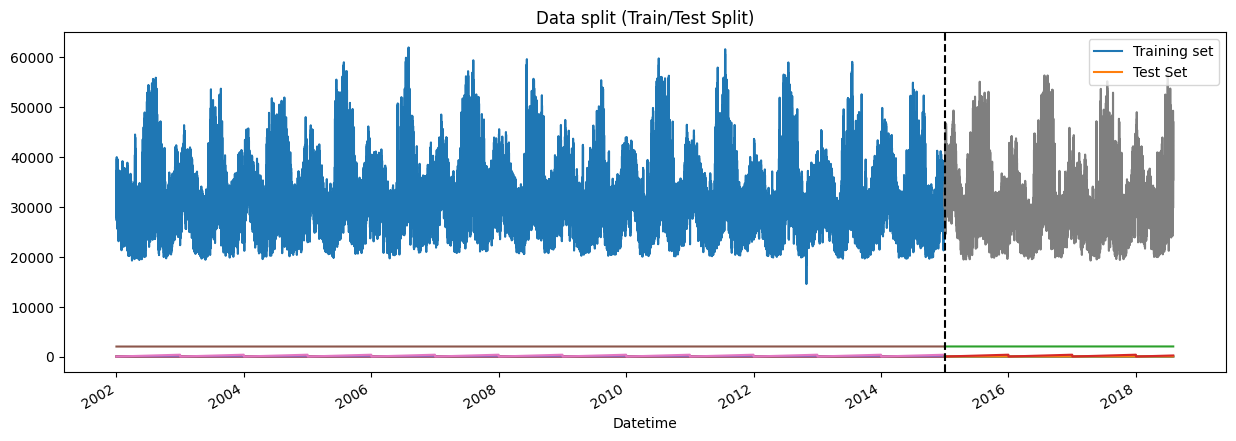

In [7]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

print(f"Training set: {len(train)} row")
print(f"Test set: {len(test)} row")

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training set', title='Data split (Train/Test Split)')
test.plot(ax=ax, label='Training set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training set', 'Test Set'])
plt.show()

In [8]:
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [9]:
import xgboost as xg


reg = xg.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)


reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32605.13970	validation_1-rmse:31657.15729


c:\Energy_Estimation_Project\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [22:57:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12584.35462	validation_1-rmse:11747.28803
[200]	validation_0-rmse:5837.33066	validation_1-rmse:5363.58554
[300]	validation_0-rmse:3923.28511	validation_1-rmse:4020.48045
[400]	validation_0-rmse:3447.54638	validation_1-rmse:3860.60088
[500]	validation_0-rmse:3288.19208	validation_1-rmse:3816.37862
[600]	validation_0-rmse:3206.55619	validation_1-rmse:3779.04119
[700]	validation_0-rmse:3153.61368	validation_1-rmse:3754.45684
[800]	validation_0-rmse:3114.34038	validation_1-rmse:3738.38209
[900]	validation_0-rmse:3084.39550	validation_1-rmse:3730.01893
[989]	validation_0-rmse:3059.85847	validation_1-rmse:3727.94591


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

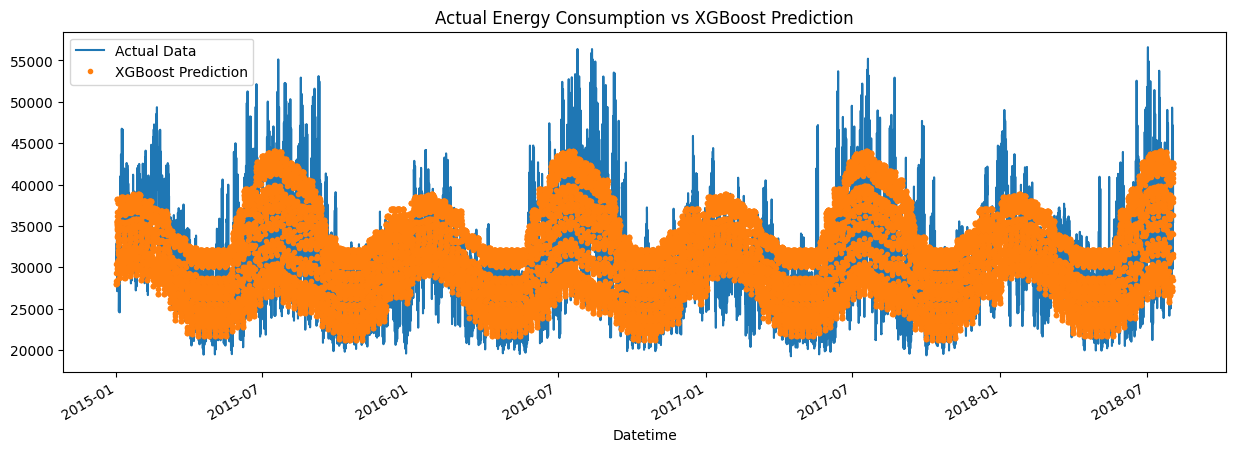

In [ ]:
test['prediction'] = reg.predict(X_test)

df_all = pd.concat([test, train], sort=False)

fig, ax = plt.subplots(figsize=(15, 5))
test['PJME_MW'].plot(ax=ax, label='Actual Data')
test['prediction'].plot(ax=ax, style='.', label='XGBoost Prediction')
plt.legend()
ax.set_title('Actual Energy Consumption vs XGBoost Prediction')
plt.show()

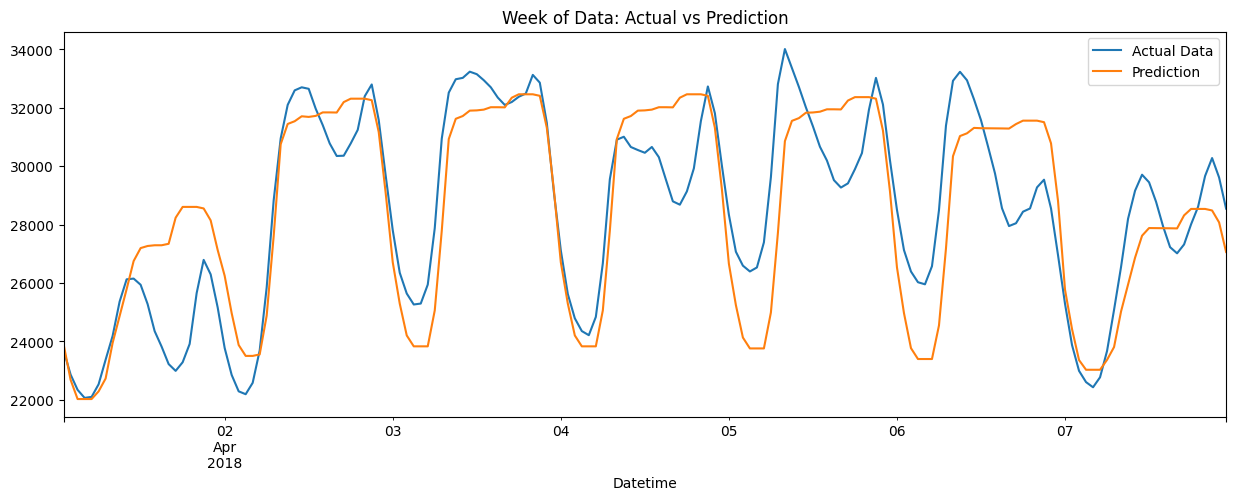

In [ ]:
df_july = test.loc[(test.index > '04-01-2018') & (test.index < '04-08-2018')]

fig, ax = plt.subplots(figsize=(15, 5))
df_july['PJME_MW'].plot(ax=ax, label='Actual Data')
df_july['prediction'].plot(ax=ax, label='Prediction')
plt.legend()
ax.set_title('Week of Data: Actual vs Prediction')
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
rmse = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
mae = mean_absolute_error(test['PJME_MW'], test['prediction'])

print(f'RMSE Score on Test set: {rmse:0.2f}')
print(f'MAE Score on Test set: {mae:0.2f}')

RMSE Score on Test set: 3726.80
MAE Score on Test set: 2902.29


In [14]:
avg_consumption = test['PJME_MW'].mean()
error_percentage = (mae / avg_consumption) * 100
print(f'Average Error Percentage: {error_percentage:0.2f}%')

Average Error Percentage: 9.27%


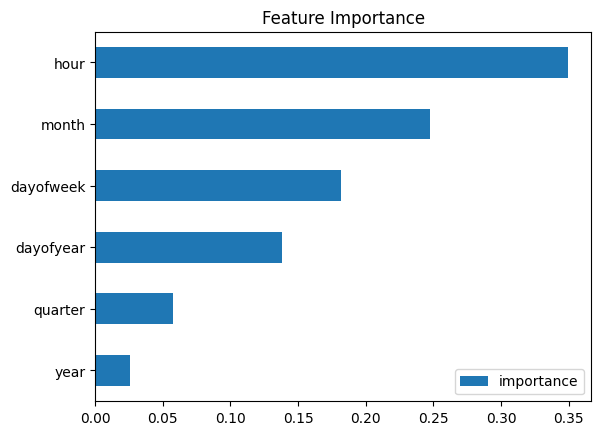

In [16]:
# feature importance
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])

fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

In [17]:
tomorrow = pd.DataFrame(index=[pd.to_datetime('2026-04-27 14:00:00')])

tomorrow['hour'] = tomorrow.index.hour
tomorrow['dayofweek'] = tomorrow.index.dayofweek
tomorrow['quarter'] = tomorrow.index.quarter
tomorrow['month'] = tomorrow.index.month
tomorrow['year'] = tomorrow.index.year
tomorrow['dayofyear'] = tomorrow.index.dayofyear

prediction_val = reg.predict(tomorrow[FEATURES])
print(f'Predicted energy consumption for tomorrow at 14:00: {prediction_val[0]:0.2f} MW')

Predicted energy consumption for tomorrow at 14:00: 31492.40 MW
